In [42]:
#Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [43]:
# Load dataset 
df = pd.read_csv("total-tree-population.csv") 

# Basic structure 
print(df.shape) 

(15962, 11)


Shape: (15962, 11)

Columns:
 ['ID', 'Age', 'Condition', 'Proximity', 'BuildingNumber', 'Street', 'Area', 'StemDiameter', 'Spread', 'Height', 'Species']

Missing values (top 15):
 Area              14016
Proximity          7407
BuildingNumber     5033
Street             1241
Height             1029
StemDiameter       1021
Spread              957
Condition           947
Age                 946
Species             152
ID                    0
dtype: int64


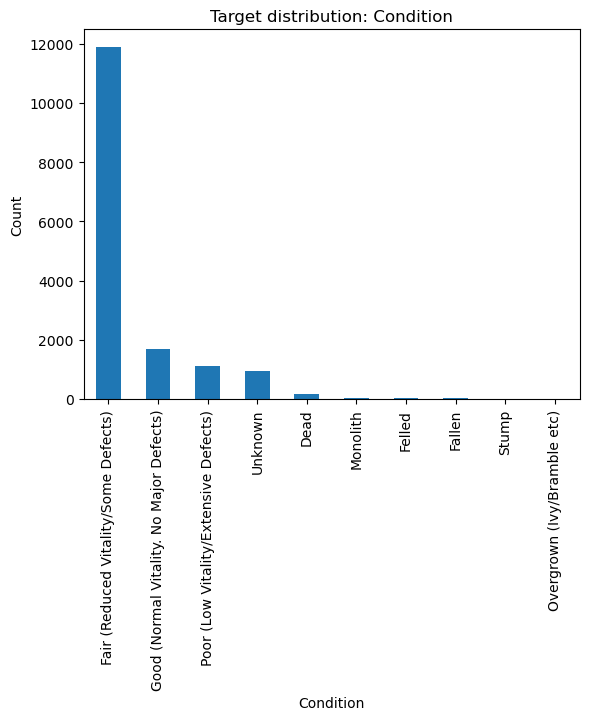

In [44]:
##B1. Load Data + Exploratory DA
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nMissing values (top 15):\n", df.isna().sum().sort_values(ascending=False).head(15))

# Target distribution
df["Condition"] = df["Condition"].fillna("Unknown")
plt.figure()
df["Condition"].value_counts().plot(kind="bar")
plt.title("Target distribution: Condition")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.show()

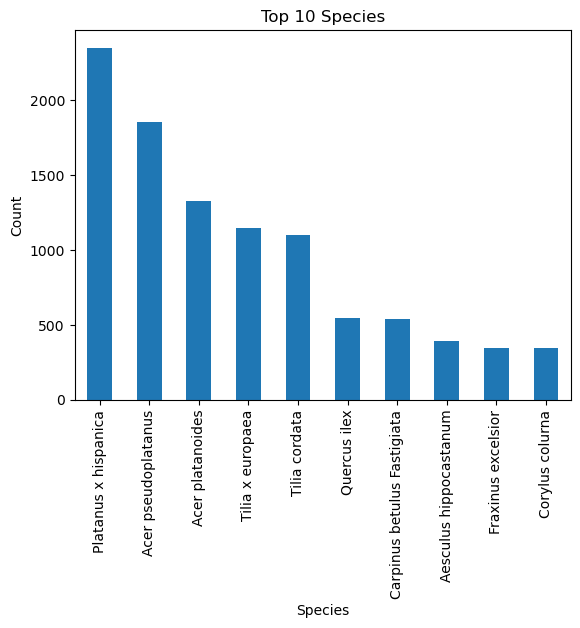

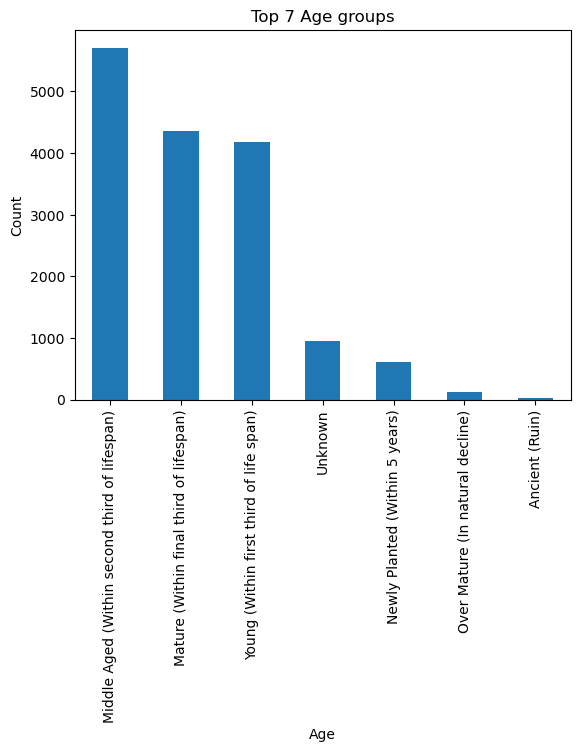

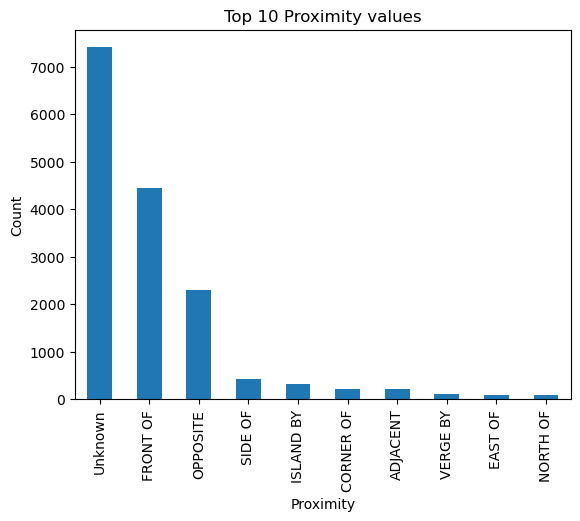

In [62]:
##B2. Feature Visuals
# 1) Species top values

plt.figure()
df["Species"].fillna("Unknown").value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

# 2) Age top values
plt.figure()
df["Age"].fillna("Unknown").value_counts().head(10).plot(kind="bar")
plt.title("Top 7 Age groups")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# 3) Proximity top values
plt.figure()
df["Proximity"].fillna("Unknown").value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Proximity values")
plt.xlabel("Proximity")
plt.ylabel("Count")
plt.show()

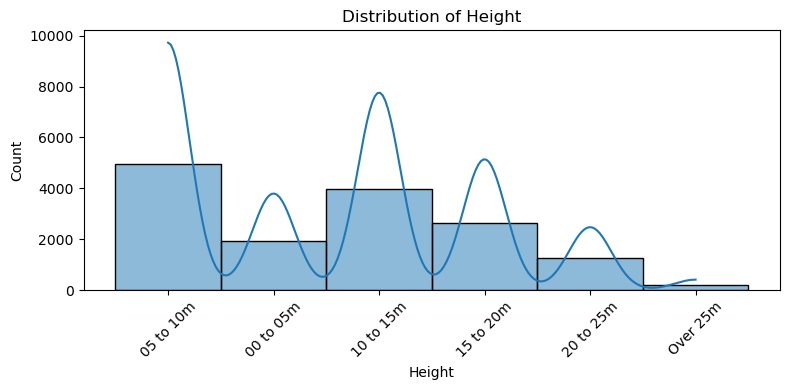

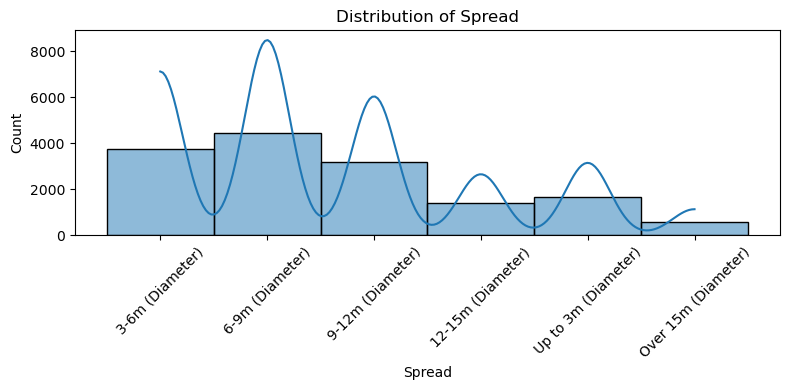

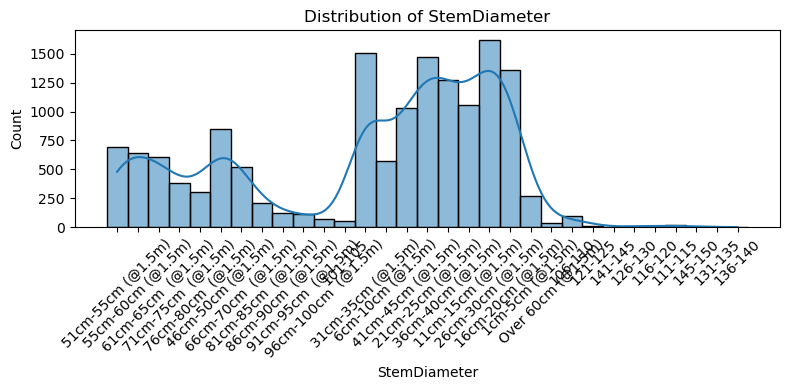

In [51]:
# Other Visualizations
for col in ['Height', 'Spread', 'StemDiameter']:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [52]:
## B4. Feature Engineering (Range text → numeric midpoints)
import re
import numpy as np

def parse_range_mid(value):
    if pd.isna(value):
        return np.nan
    nums = re.findall(r"(\d+(?:\.\d+)?)", str(value))
    if len(nums) >= 2:
        a, b = float(nums[0]), float(nums[1])
        return (a + b) / 2
    if len(nums) == 1:
        return float(nums[0])
    return np.nan

df["StemDiameter_cm_mid"] = df["StemDiameter"].apply(parse_range_mid)
df["Height_m_mid"] = df["Height"].apply(parse_range_mid)
df["Spread_m_mid"] = df["Spread"].apply(parse_range_mid)

print(df[["StemDiameter", "StemDiameter_cm_mid"]].head(5))
print(df[["Height", "Height_m_mid"]].head(5))
print(df[["Spread", "Spread_m_mid"]].head(5))

  StemDiameter  StemDiameter_cm_mid
0          NaN                  NaN
1          NaN                  NaN
2          NaN                  NaN
3          NaN                  NaN
4          NaN                  NaN
  Height  Height_m_mid
0    NaN           NaN
1    NaN           NaN
2    NaN           NaN
3    NaN           NaN
4    NaN           NaN
  Spread  Spread_m_mid
0    NaN           NaN
1    NaN           NaN
2    NaN           NaN
3    NaN           NaN
4    NaN           NaN


In [53]:
####C. Model Implementation & Training (2 models)
###C1. Prepare X/Y + Split (Code)
from sklearn.model_selection import train_test_split

# Target
df["Condition"] = df["Condition"].fillna("Unknown")

# Optional: group rare labels to reduce noise (keeps model stable)
vc = df["Condition"].value_counts()
rare_labels = vc[vc < 50].index
df.loc[df["Condition"].isin(rare_labels), "Condition"] = "Other"

y = df["Condition"]

feature_cols = ["Age", "Proximity", "Area", "Species", "StemDiameter_cm_mid", "Height_m_mid", "Spread_m_mid"]
X = df[feature_cols].copy()

num_cols = ["StemDiameter_cm_mid", "Height_m_mid", "Spread_m_mid"]
cat_cols = [c for c in feature_cols if c not in num_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (12769, 7) Test shape: (3193, 7)


In [54]:
###C2. Build Preprocessing Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

In [55]:
##C3. Model 1: Logistic Regression
from sklearn.linear_model import LogisticRegression

log_reg = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=1000))
])

log_reg.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['StemDiameter_cm_mid',
                                                   'Height_m_mid',
                                                   'Spread_m_mid']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Age', 'Proximity', 'Area',
                                                   'Species'])])),
                ('clf', LogisticRegression(max_iter=1000))])

In [59]:
##C4. Model 2: Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

rf.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['StemDiameter_cm_mid',
                                                   'Height_m_mid',
                                                   'Spread_m_mid']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Age', 'Proximity', 'Area',
                                                   'Species'])])),
                ('clf',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [58]:
print("Accuracy:", accuracy_score(y_test, pred_rf))
print("F1-macro:", f1_score(y_test, pred_rf, average="macro"))

Accuracy: 0.7453805198872534
F1-macro: 0.48566579605824284


In [61]:
###D. Evaluation & Comparison
##D1. Evaluate Both Models (Accuracy + F1-macro)
from sklearn.metrics import accuracy_score, f1_score, classification_report

pred_lr = log_reg.predict(X_test)
pred_rf = rf.predict(X_test)

print("Logistic Regression")
print("Accuracy:", round(accuracy_score(y_test, pred_lr), 4))
print("F1-macro:", round(f1_score(y_test, pred_lr, average="macro"), 4))
print(classification_report(y_test, pred_lr))

print("\nRandom Forest")
print("Accuracy:", round(accuracy_score(y_test, pred_rf), 4))
print("F1-macro:", round(f1_score(y_test, pred_rf, average="macro"), 4))
print(classification_report(y_test, pred_rf))

Logistic Regression
Accuracy: 0.8033
F1-macro: 0.399
                                          precision    recall  f1-score   support

                                    Dead       0.60      0.32      0.42        37
    Fair (Reduced Vitality/Some Defects)       0.81      0.98      0.89      2378
Good (Normal Vitality. No Major Defects)       0.77      0.14      0.23       338
                                Monolith       0.50      0.20      0.29        10
                                   Other       0.00      0.00      0.00        16
   Poor (Low Vitality/Extensive Defects)       0.44      0.08      0.14       225
                                 Unknown       0.86      0.79      0.83       189

                                accuracy                           0.80      3193
                               macro avg       0.57      0.36      0.40      3193
                            weighted avg       0.77      0.80      0.75      3193


Random Forest
Accuracy: 0.7454


C:\Users\hopeo\Downloads\Hope Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hopeo\Downloads\Hope Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hopeo\Downloads\Hope Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

F1-macro: 0.4857
                                          precision    recall  f1-score   support

                                    Dead       0.25      0.35      0.30        37
    Fair (Reduced Vitality/Some Defects)       0.87      0.81      0.84      2378
Good (Normal Vitality. No Major Defects)       0.49      0.56      0.52       338
                                Monolith       0.43      0.60      0.50        10
                                   Other       0.04      0.06      0.05        16
   Poor (Low Vitality/Extensive Defects)       0.24      0.35      0.28       225
                                 Unknown       0.90      0.93      0.91       189

                                accuracy                           0.75      3193
                               macro avg       0.46      0.52      0.49      3193
                            weighted avg       0.78      0.75      0.76      3193

